In [1]:
import pandas as pd

read_position_dependence_csv = pd.read_csv("../../output/zymo/ERR3152366.summary_read_position_stats.csv")
#read_position_dependence_csv = pd.read_csv("../../output/zymo/ERR2935851_assembly.summary_read_position_stats.csv")
read_position_dependence_csv.head()


,read_position,from_start,matches,mismatches,insertions,deletions,clipped,skipped
0,1,True,3590,0,0,0,3391469,0
1,2,True,5079,0,0,0,3389980,0
2,3,True,6437,0,0,0,3388622,0
3,4,True,7708,71,0,7,3387280,0
4,5,True,8739,113,33,54,3386174,0


In [2]:
read_position_dependence_csv["num_bases"] = read_position_dependence_csv["matches"] + \
    read_position_dependence_csv["mismatches"] + \
    read_position_dependence_csv["insertions"] # + \
    #read_position_dependence_csv["deletions"] # + \
    #read_position_dependence_csv["clipped"]
read_position_dependence_csv["error_rate"] = 1 - (read_position_dependence_csv["matches"] / read_position_dependence_csv["num_bases"])

In [3]:
1 - read_position_dependence_csv["matches"].sum() / read_position_dependence_csv["num_bases"].sum()

0.0733466656659505

In [4]:
read_position_dependence_csv.iloc[100:200]

,read_position,from_start,matches,mismatches,insertions,deletions,clipped,skipped,num_bases,error_rate
100,101,True,2950619,126114,99985,145453,218340,0,3176718,0.071174
101,102,True,2951072,126360,100288,146603,217338,0,3177720,0.071324
102,103,True,2952450,126426,99876,145788,216306,0,3178752,0.071192
103,104,True,2951702,127156,100842,147068,215358,0,3179700,0.071704
104,105,True,2953563,126795,100313,147206,214387,0,3180671,0.071403
...,...,...,...,...,...,...,...,...,...,...
195,196,True,2991487,133230,101450,157502,168686,0,3226167,0.072743
196,197,True,2991832,133401,101214,157883,168400,0,3226447,0.072716
197,198,True,2992503,133459,100762,156997,168116,0,3226724,0.072588
198,199,True,2993184,133172,100618,158633,167858,0,3226974,0.072449


Text(0.5, 1.0, 'Error Rate vs Position from Start of Read')

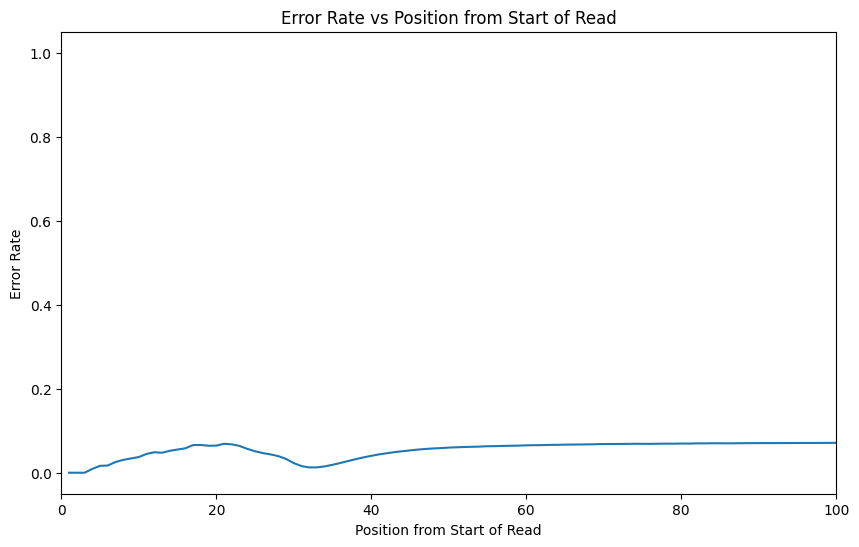

In [4]:
read_position_from_start = read_position_dependence_csv[read_position_dependence_csv["from_start"] == True]

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(read_position_from_start["read_position"], read_position_from_start["error_rate"], label="Error Rate")
plt.xlabel("Position from Start of Read")
plt.ylabel("Error Rate")
plt.xlim(0, 100)
plt.title("Error Rate vs Position from Start of Read")

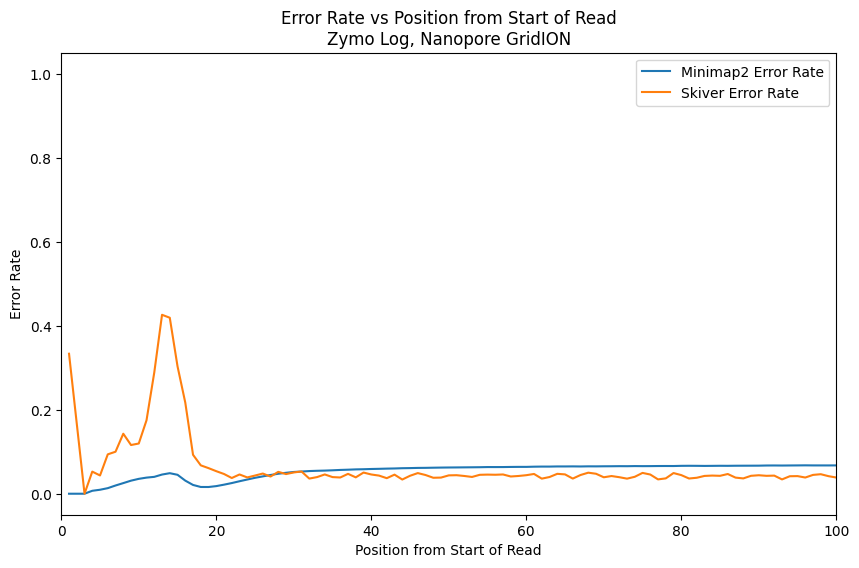

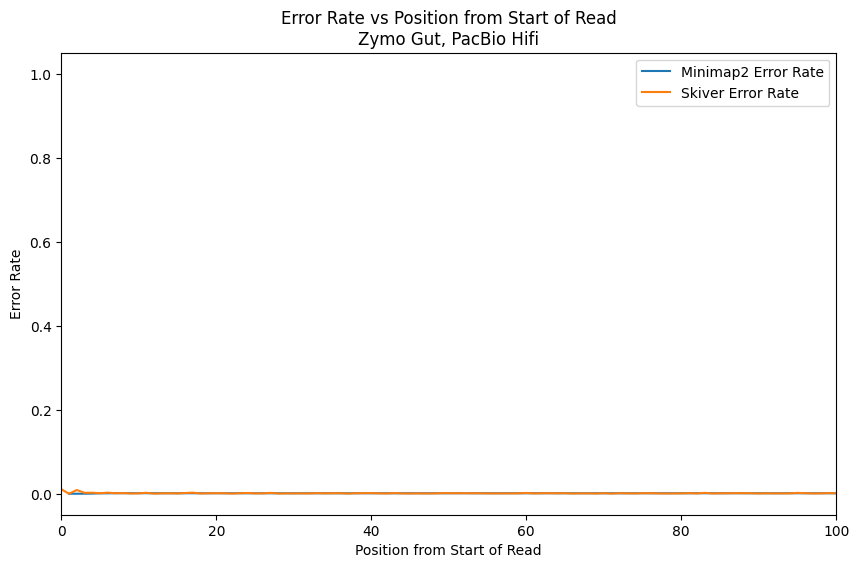

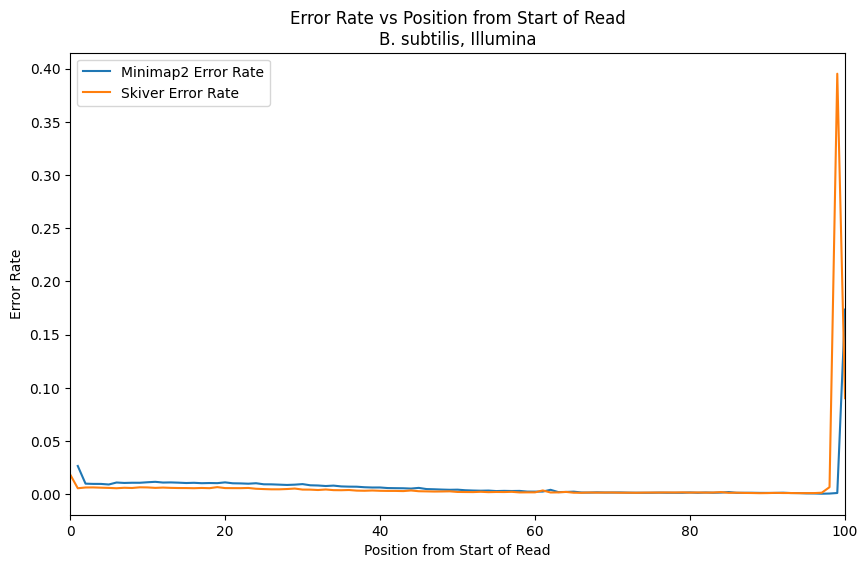

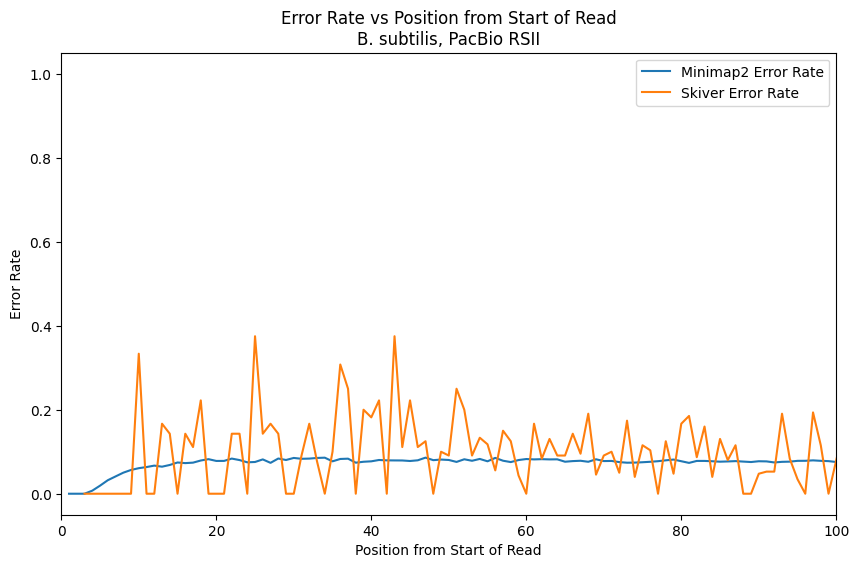

In [8]:
minimap_results = [
    "../../output/zymo/ERR3152366.summary_read_position_stats.csv",
    "../../output/zymo/SRR13128014.summary_read_position_stats.csv",
    "../../output/zymo/ERR2935851_assembly.summary_read_position_stats.csv",
    "../../output/zymo/SRR7498042_assembly.summary_read_position_stats.csv",
]

skiver_results = [
    "../../output/zymo/skiver/ERR3152366.summary_read_position.csv",
    "../../output/zymo/skiver/SRR13128014.summary_read_position.csv",
    "../../output/zymo/skiver/ERR2935851.summary_read_position.csv",
    "../../output/zymo/skiver/SRR7498042.summary_read_position.csv",
]

dataset_names = [
    "Zymo Log, Nanopore GridION",
    "Zymo Gut, PacBio Hifi",
    "B. subtilis, Illumina",
    "B. subtilis, PacBio RSII"
]
    

for minimap_result, skiver_result, name in zip(minimap_results, skiver_results, dataset_names):
    minimap_csv = pd.read_csv(minimap_result)
    skiver_csv = pd.read_csv(skiver_result)

    minimap_csv["num_bases"] = minimap_csv["matches"] + \
        minimap_csv["mismatches"] + \
        minimap_csv["insertions"] 
        # minimap_csv["deletions"] # + \
        #minimap_csv["clipped"]
    minimap_csv["error_rate"] = 1 - (minimap_csv["matches"] / minimap_csv["num_bases"])

    #print(minimap_csv.head())


    minimap_from_start = minimap_csv[minimap_csv["from_start"] == False]
    skiver_from_start = skiver_csv[skiver_csv["from_start"] == False]

    plt.figure(figsize=(10, 6))
    plt.plot(minimap_from_start["read_position"], minimap_from_start["error_rate"], label="Minimap2 Error Rate")
    plt.plot(skiver_from_start["index"], skiver_from_start["error_rate"], label="Skiver Error Rate")
    plt.xlabel("Position from Start of Read")
    plt.ylabel("Error Rate")
    plt.xlim(0, 100)
    plt.title(f"Error Rate vs Position from Start of Read\n{name}")
    plt.legend()

In [33]:
read_position_dependence_csv.iloc[50:100]

,read_position,from_start,matches,mismatches,insertions,deletions,num_bases,error_rate
50,51,True,44964740,164899,729,1173,45131541,0.003696
51,52,True,44942048,189651,720,1181,45133600,0.004244
52,53,True,44948915,184051,728,1167,45134861,0.004120
53,54,True,44939787,193283,818,1146,45135034,0.004326
54,55,True,44926819,205725,762,961,45134267,0.004596
55,56,True,44916309,214485,825,1100,45132719,0.004795
56,57,True,44862175,264856,830,1143,45129004,0.005913
57,58,True,44885768,235675,869,1186,45123498,0.005268
58,59,True,44865693,248734,873,1164,45116464,0.005558
59,60,True,44853038,252587,861,1171,45107657,0.005645
